#7장

In [1]:
#dataset download
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("샘플 개수:", len(data))

샘플 개수: 1100


In [2]:
print("샘플 예시:\n",data[50])

샘플 예시:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
print("다른 샘플 예시:\n",data[999])

다른 샘플 예시:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [4]:
#data list의 항목을 알파카 prompt style의 형태로 변환
def format_input(entry):
  instruction_text=(
      f"Below is an instruction that describes a task."
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"
  )

  #json 파일의 input field가 비어 있으면 밑의 섹션을 건너뛴다.
  input_text=(
      f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
  )
  return instruction_text +input_text

In [5]:
model_input=format_input(data[50])
desired_response=f"\n\n### Response:\n{data[50]['output']}"
print(model_input+desired_response)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input=format_input(data[999])
desired_response=f"\n\n### Response:\n{data[999]['output']}"
print(model_input+desired_response)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [7]:
#dataset을 trainset, validset, testset으로 나눈다.
train_portion=int(len(data) * 0.85)
test_portion=int(len(data)*0.1)
val_portion=len(data)-train_portion-test_portion

train_data=data[:train_portion]
test_data=data[train_portion:test_portion+train_portion]
val_data=data[test_portion+train_portion:]

print("훈련 세트 크기:",len(train_data))
print("검증 세트 크기:",len(val_data))
print("테스트 세트 크기:",len(test_data))

훈련 세트 크기: 935
검증 세트 크기: 55
테스트 세트 크기: 110


In [8]:
#dataset의 모든 샘플에 format_input()을 적용하고, tokenization해보겠다.
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
  def __init__(self,data,tokenizer):
    self.data=data
    self.encoded_texts=[]
    for entry in data:
      instruction_plus_input=format_input(entry)
      response_text=f"\n\n### Response:\n{entry['output']}"
      full_text=instruction_plus_input+response_text
      self.encoded_texts.append(
          tokenizer.encode(full_text)
      )
  def __getitem__(self, index):
    return self.encoded_texts[index]
  def __len__(self):
    return len(self.data)

In [9]:
#패딩 추가하여 모든 시퀀스의 길이를 맞춘다.
def custom_collate_draft_1(
    batch, pad_token_id=50256,device="cpu"):
  #batch에서 가장 긴 시퀀스를 찾는다.
  batch_max_length=max(len(item)+1 for item in batch)
  inputs_lst=[]

  #입력에 패딩을 추가한다.
  for item in batch:
    new_item=item.copy()
    new_item+=[pad_token_id]

    padded=(
        new_item+[pad_token_id]*(batch_max_length-len(new_item))
    )
    inputs=torch.tensor(padded[:-1])
    inputs_lst.append(inputs)

  inputs_tensor=torch.stack(inputs_lst).to(device)
  return inputs_tensor

In [10]:
#위 함수 테스트
inputs_1=[0,1,2,3,4]
inputs_2=[5,6]
inputs_3=[7,8,9]
batch=(
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [11]:
#target tokenID로 구성된 batch도 만든다.
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device='cpu'):

  batch_max_length=max(len(item)+1 for item in batch)
  inputs_lst,targets_lst=[],[]

  for item in batch:
    new_item=item.copy()
    new_item.append(pad_token_id)
    padded=(
        new_item+[pad_token_id]*(batch_max_length - len(new_item))
    )
    #입력에서 마지막 token을 삭제한다.
    inputs=torch.tensor(padded[:-1])
    #오른쪽으로 하나 이동하여 target을 만든다.
    targets=torch.tensor(padded[1:])
    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor=torch.stack(inputs_lst).to(device)
  targets_tensor=torch.stack(targets_lst).to(device)
  return inputs_tensor,targets_tensor

inputs,targets=custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [12]:
#최종적인 전처리 함수
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"):
  batch_max_length=max(len(item)+1 for item in batch)
  inputs_lst,targets_lst=[],[]

  for item in batch:
    new_item=item.copy()
    new_item+=[pad_token_id]

    padded=(
        new_item + [pad_token_id]*(batch_max_length-len(new_item))
    )
    inputs=torch.tensor(padded[:-1])
    targets=torch.tensor(padded[1:])
    mask=targets==pad_token_id
    indices=torch.nonzero(mask).squeeze()
    if indices.numel()>1:
      targets[indices[1:]]=ignore_index

    if allowed_max_length is not None:
      inputs=inputs[:allowed_max_length]
      targets=targets[:allowed_max_length]

    inputs_lst.append(inputs)
    targets_lst.append(targets)

  inputs_tensor=torch.stack(inputs_lst).to(device)
  targets_tensor=torch.stack(targets_lst).to(device)
  return inputs_tensor, targets_tensor

In [13]:
#위 함수 테스트
inputs, targets=custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [14]:
logits_1=torch.tensor(
    [[-1.0,1.0],  #첫 번째 token에 대한 예측
     [-0.5,1.5]]  #두 번째 token에 대한 예측
)
targets_1=torch.tensor([0,1]) #정답 token index
loss_1=torch.nn.functional.cross_entropy(logits_1,targets_1)
print(loss_1)

tensor(1.1269)


In [15]:
logits_2=torch.tensor(
    [[-1.0,1.0],  #첫 번째 token에 대한 예측
     [-0.5,1.5],  #두 번째 token에 대한 예측
     [-0.5,1.5]]  #세 번째 token에 대한 예측
)
targets_2=torch.tensor([0,1,1]) #정답 token index
loss_2=torch.nn.functional.cross_entropy(logits_2,targets_2)
print(loss_2)

tensor(0.7936)


In [16]:
targets_3=torch.tensor([0,1,-100])
loss_3=torch.nn.functional.cross_entropy(logits_2,targets_3)
print(loss_3)
print("loss-1==loss_3:",loss_1==loss_3)

tensor(1.1269)
loss-1==loss_3: tensor(True)


Dataloader 만들기

In [17]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("장치: ",device)

장치:  cuda


In [18]:
from functools import partial

customized_collate_fn=partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)


In [19]:
#dataloader 초기화
from torch.utils.data import DataLoader
import tiktoken

tokenizer=tiktoken.get_encoding("gpt2")
num_workers=0
batch_size=8

torch.manual_seed(123)

train_dataset=InstructionDataset(train_data,tokenizer)
train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset=InstructionDataset(val_data,tokenizer)
val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset=InstructionDataset(test_data,tokenizer)
test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)


In [20]:
print("훈련 데이터 로더:")
for inputs,targets in train_loader:
  print(inputs.shape,targets.shape)

훈련 데이터 로더:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Siz

fine-tuning을 위해 LLM을 로드한다.

In [ ]:
!wget https://github.com/udasuja/study_LLM/raw/main/previous_chapters.py

In [ ]:
!wget https://github.com/udasuja/study_LLM/raw/main/gpt_download.py

In [ ]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel
from previous_chapters import load_weights_into_gpt

BASE_CONFIG={
    "vocab_size":50257,     #vocabulary size
    "context_length":1024,  #context_length
    "drop_rate":0.0,        #dropout ratio
    "qkv_bias":True         #bias for query-key-value
}

model_configs={
    "gpt2-small (124M)":{"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium (355M)":{"emb_dim":1024,"n_layers":24,"n_heads":16},
    "gpt2-large (774M)":{"emb_dim":1280,"n_layers":36,"n_heads":20},
    "gpt2-xl (1558M)":{"emb_dim":1600,"n_layers":48,"n_heads":25},
}

CHOOSE_MODEL="gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size=CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params=download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model,params)
model.eval()

pre-trained LLM의 성능을 평가

In [30]:
#지시 내용은 출력
torch.manual_seed(123)
input_text=format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [34]:
#pre-trained된 모델의 응답 생성
from previous_chapters import generate,text_to_token_ids,token_ids_to_text
token_ids=generate(
    model=model,
    idx=text_to_token_ids(input_text,tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generate_text=token_ids_to_text(token_ids,tokenizer)

In [36]:
#모델이 아직 주어진 지시를 올바르게 수행하는 능력이 없음을 보여준다. 그저 전에 했던 말을 반복할 뿐이다.
response_text=generate_text[len(input_text):].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


#Fine-Tuning

In [37]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)

In [38]:
#train set과 valid set에 대한 loss을 계산
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss=calc_loss_loader(
      train_loader,model,device,num_batches=5
  )
  val_loss=calc_loss_loader(
      val_loader,model,device,num_batches=5
  )

print("훈련 손실:", train_loss)
print("검증 손실:", val_loss)

훈련 손실: 4.013568258285522
검증 손실: 3.9385430812835693


In [41]:
#optimazer 초기화, epoch 설정 등 훈련 과정을 설정한다.
#본격적인 LLM을 instruction fine-tuning 해보겠다.
import time

start_time=time.time()
torch.manual_seed(123)
optimizer=torch.optim.AdamW(
    model.parameters(),lr=0.00005,weight_decay=0.1
)
num_epochs=2

train_losses,val_losses,tokens_seen=train_model_simple(
    model,train_loader,val_loader,optimizer,device,
    num_epochs=num_epochs,eval_freq=5,eval_iter=5,
    start_context=format_input(val_data[0]),tokenizer=tokenizer
)

end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f"훈련 소요 시간: {execution_time_minutes:.2f}분")

Ep 1 (Step 000000): Train loss 0.959, Val loss 1.052
Ep 1 (Step 000005): Train loss 0.941, Val loss 0.908
Ep 1 (Step 000010): Train loss 0.761, Val loss 0.885
Ep 1 (Step 000015): Train loss 0.774, Val loss 0.859
Ep 1 (Step 000020): Train loss 0.706, Val loss 0.833
Ep 1 (Step 000025): Train loss 0.692, Val loss 0.803
Ep 1 (Step 000030): Train loss 0.733, Val loss 0.790
Ep 1 (Step 000035): Train loss 0.673, Val loss 0.776
Ep 1 (Step 000040): Train loss 0.627, Val loss 0.773
Ep 1 (Step 000045): Train loss 0.596, Val loss 0.762
Ep 1 (Step 000050): Train loss 0.606, Val loss 0.753
Ep 1 (Step 000055): Train loss 0.710, Val loss 0.738
Ep 1 (Step 000060): Train loss 0.662, Val loss 0.722
Ep 1 (Step 000065): Train loss 0.605, Val loss 0.711
Ep 1 (Step 000070): Train loss 0.491, Val loss 0.709
Ep 1 (Step 000075): Train loss 0.534, Val loss 0.708
Ep 1 (Step 000080): Train loss 0.561, Val loss 0.696
Ep 1 (Step 000085): Train loss 0.460, Val loss 0.684
Ep 1 (Step 000090): Train loss 0.523, Val loss

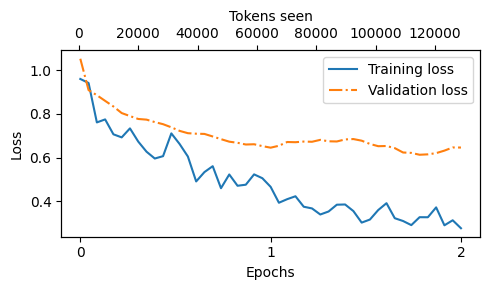

In [42]:
#학습 과정을 보여주는 train loss curve과 valid loss curve
from previous_chapters import plot_losses
epochs_tensor=torch.linspace(0,num_epochs,len(train_losses))
plot_losses(epochs_tensor,tokens_seen,train_losses,val_losses)

test set에서 모델의 성능을 평가

In [44]:
torch.manual_seed(123)

#처음 3개의 test set sample을 순회한다.
for entry in test_data[:3]:
  input_text=format_input(entry)
  token_ids=generate(
      model=model,
      idx=text_to_token_ids(input_text,tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generated_text=token_ids_to_text(token_ids,tokenizer)

  response_text=(
      generated_text[len(input_text):].replace("### Response:","").strip()
  )
  print(input_text)
  print(f"\n올바른 응답:\n>> {entry['output']}")
  print(f"\n모델 응답:\n>> {response_text.strip()}")
  print("---------------------------------------\n\n\n")

Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

올바른 응답:
>> The car is as fast as lightning.

모델 응답:
>> The car is as fast as a bullet.
---------------------------------------



Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

올바른 응답:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

모델 응답:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
---------------------------------------



Below is an instruction that describes a task.Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

올바른 응답:
>> Jane Austen.

모델 응답:
>> The author of 'Pride and Prejudice' is Jane Austen.
---------------------------

In [46]:
#전체 test_data를 순회하고 모델 응답을 출력하지 않고 test_data dictionary에 추가한다.
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
  input_text=format_input(entry)

  token_ids=generate(
      model=model,
      idx=text_to_token_ids(input_text,tokenizer).to(device),
      max_new_tokens=256,
      context_size=BASE_CONFIG["context_length"],
      eos_id=50256
  )
  generate_text=token_ids_to_text(token_ids,tokenizer)

  response_text=(
      generated_text[len(input_text):].replace("### Response:","").strip()
  )
  test_data[i]["model_response"]=response_text

with open("instruction-data-with-response.json","w") as file:
  json.dump(test_data,file,indent=4)

100%|██████████| 110/110 [01:34<00:00,  1.16it/s]


In [47]:
#잘 추가되었는지 확인
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': "'Pride and Prejudice' is Jane Austen."}


In [48]:
#모델을 저장한다(선택).
import re
file_name=f"{re.sub(r'[ ()]','',CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(),file_name)
print(f"모델이 {file_name}에 저장되었습니다.")

모델이 gpt2-medium355M-sft.pth에 저장되었습니다.


In [ ]:
#AlpacaEval의 방식을 따라서 다른 LLM을 사용해 fine-tuning된 모델의 응답을 평가한다.
#여기서는 llama3 모델을 사용하겠다.
#이를 위해 colab에서 ollama설정을 하겠다.
!sudo apt-get install -y zstd

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

In [52]:
import subprocess
import time

# 서버를 백그라운드에서 실행
subprocess.Popen(["ollama", "serve"])
time.sleep(3) # 서버가 완전히 켜질 때까지 잠시 대기

In [53]:
!ollama pull llama3.1

llama로 fine-tuning된 모델 평가하기

In [56]:
import urllib.request

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
#payload 데이터를 dictionary로 만든다.
  data={
      "model":model,
      "messages":[
          {"role":"user","content":prompt}
      ],
      #결정론적인 응답을 위해 설정한다.
      "options":{
          "seed":123,
          "tmperature":0,
          "num_ctx":2048
      }
  }
  #dictionary를 JSON 형식의 문자열로 변환하고 byte로 encoding한다.
  payload=json.dumps(data).encode("utf-8")
  #method를 POST로 지정하고 필요한 header를 추가하여 요청 객체를 만든다.
  request=urllib.request.Request(
      url,
      data=payload,
      method="POST"
  )

  request.add_header("Content-Type","application/json")

  response_data=""
  with urllib.request.urlopen(request) as response:
    while True:
      line=response.readline().decode("utf-8")
      if not line:
        break
        response_json=json.loads(line)
        response_data+=response_json["message"]["content"]

  return response_data


In [ ]:
model="llama3"
result=query_model("What do Llamas eat?", model)
print(result)

In [ ]:
#query_model 함수를 사용해 fine-tuning된 model이 생성한 응답을 평가할 수 있으며
#Llama 3 model에게 참조로 제공된 test set 응답을 바탕으로 fine-tuning된 model의 응답을 0에서 100 사이의 척도로 평가하도록 요청할 수 있다.

#이 방법을 test set에 있는 처음 3개의 sample에 적용
for entry in test_data[:3]:
  prompt=(
      f"Given the input '{format_input(entry)}'"
      f"and correct output '{entry['output']}', "
      f"score the model response '{entry['model_response']}'"
      f" on a scale from 0 to 100, where 100 is the best score. "
  )
  print("\n데이터셋 응답:")
  print(">>",entry['output'])
  print("\n모델 응답:")
  print(">>",entry["model_response"])
  print("\n점수:")
  print(">>",query_model(prompt))
  print("\m------------------------")



데이터셋 응답:
>> The car is as fast as lightning.

모델 응답:
>> The car is as fast as a bullet.

점수:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might not immediately think of a bullet when they hear "fast", whereas lightning is often an intuitive comparison for speed. However, "a bullet" is still a good choice and effectively conveys the idea that the car is very quick!

-------------------------

데이터셋 응답:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

모델 응답:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

점수:
>> I'd score this model response as 40 out of 100.

Here's why:

* The model correctly identifies that thunderstorms are related to clouds (correctly identifying the type of phenomenon).
* However, it incorrectly specifies the type of cloud associated with thunderstorms. Cumulus clouds are not typically associated with thunderstorms; cumulonimbus clouds are.
* The response lacks precision and accuracy in its description.

Overall, while the model attempts to address the instruction, it doesn't provide an accurate or precise answer.

-------------------------

데이터셋 응답:
>> Jane Austen.

모델 응답:
>> The author of 'Pride and Prejudice' is Jane Austen.

점수:
>> I'd rate my own response as 95 out of 100. Here's why:

* The response accurately answers the question by naming the author of 'Pride and Prejudice' as Jane Austen.
* The response is concise and clear, making it easy to understand.
* There are no grammatical errors or inaccuracies in the response.

The only reason I wouldn't give myself a perfect score is that the response is slightly redundant - it's not necessary to rephrase the question in the answer. A more concise response would be simply "Jane Austen."

-------------------------

In [59]:
#fine-tuning된 LLM 평가
def generate_model_scores(json_data, json_key,model="llama3"):
  scores=[]
  for entry in tqdm(json_data,desc="평가 항목"):
    prompt=(
        f"Given the input '{format_input(entry)}'"
        f"and correct output '{entry['output']}', "
        f"score the model response '{entry['model_response']}'"
        f" on a scale from 0 to 100, where 100 is the best score. "
        f"Respond with the integer number only."
    )
    score=query_model(prompt,model)
    try:
      scores.append(int(score))
    except ValueError:
      print(f"점수로 변환할 수 없습니다: {score}")
      continue

  return scores

In [ ]:
#전체 test_data 평가
scores=generate_model_scores(test_data,"model_response")
print(f"평가 횟수: {len(test_data)}개 중 {len(scores)}개")
print(f"평균 점수: {sum(scores)/len(scores):.2f}\n")